# Reproduce Sushma's results using embedding learning approach which is very similar as S3

### 0. Assume we have done the ABM simulation and the datasets are graph-structured

All the graph-structured datasets we need here are in the main file named 'finaldata'.

### 1. Install Packages

In [1]:
pip install torch_geometric

     ---------------------------------------- 1.1/1.1 MB 14.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install tensorboard

     ---------------------------------------- 5.5/5.5 MB 17.6 MB/s eta 0:00:00
     ---------------------------------------- 4.3/4.3 MB 13.6 MB/s eta 0:00:00
     ------------------------------------- 431.0/431.0 kB 26.3 MB/s eta 0:00:00
     -------------------------------------- 135.6/135.6 kB 7.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install tsne_torch

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for tsne_torch: filename=tsne_torch-1.0.1-py3-none-any.whl size=5618 sha256=62b68f983bad4a09d71d7812d28247f7dbae7a0e31063ec4ac7dd2023ba22c5d
  Stored in directory: c:\users\mechrev\appdata\local\pip\cache\wheels\13\2b\52\810d21c5fabc59220484813a0916b8bd0f11860aea27eda609
Successfully built tsne_torch
Note: you may need to restart the kernel to use updated packages.


### 2. Import packages

In [2]:
import os
import time
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import defaultdict
from tqdm import tqdm
import random
from itertools import combinations, permutations, product
from torch.utils.data import DataLoader
from torch.optim import Adam
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import pickle as pk
from datetime import datetime

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.utils as pyg_utils
from tsne_torch import TorchTSNE as TSNE
from torch.utils.tensorboard import SummaryWriter
from torch_geometric.utils import from_networkx
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data, Dataset
from torch_geometric.nn import GCNConv, global_mean_pool, GATConv

In [3]:
ur_path = 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data'  # your path to the data files

### 3. Go over all the file names starting with "Trackrefiner" (10x100=1000)

Simple_GAT.ipynb

In [4]:
directory = "C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata"

In [5]:
#folder of the data generated by sims_relationships.ipynb
def get_file_names(directory):

    # Collect files starting with "Trackrefiner"
    matching_files = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.startswith("Trackrefiner"):
                matching_files.append(os.path.join(root, file))

    return matching_files

In [6]:
matching_files = get_file_names(directory)

In [7]:
matching_files[:3]

['C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata\\iteration 00\\Trackrefiner.gamma_100_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_013.csv',
 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata\\iteration 00\\Trackrefiner.gamma_100_reg_param_0.01_adh_0.1-Average-0result.csv-analysis_038.csv',
 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata\\iteration 00\\Trackrefiner.gamma_100_reg_param_0.01_adh_1-Average-0result.csv-analysis_079.csv']

In [8]:
len(matching_files)  # 10 iterations and 100 files for each

1000

### 4. Sort all the sample labels (10x100=1000)

In [9]:
#Identifying parameter combinations
def identify_parameter_combinations(matching_files):
    variations_with_instances = np.unique(list(map(lambda x: x.split('Trackrefiner.')[1].split('result')[0], matching_files)))

    # Initialize sets to collect unique values
    unique_gamma = set()
    unique_reg_param = set()
    unique_adh = set()
    unique_average = set()


    # Extract parameter values
    for var in variations_with_instances:
        # Remove the instance part
        base_var, average = var.split('-Average-')
        uni_average = average[0]
        # Parse the gamma, reg_param, and adh values
        parts = base_var.split('_')
        gamma = parts[1]
        reg_param = parts[4]
        adh = parts[6]

        # Add to respective sets
        unique_gamma.add(gamma)
        unique_reg_param.add(reg_param)
        unique_adh.add(adh)
        unique_average.add(uni_average)

    # Convert to sorted lists (optional)
    unique_gamma = list(sorted(unique_gamma))
    unique_reg_param = list(sorted(unique_reg_param))
    unique_adh = list(sorted(unique_adh))
    return unique_gamma, unique_reg_param, unique_adh

In [10]:
unique_gamma, unique_reg_param, unique_adh = identify_parameter_combinations(matching_files)

In [11]:
unique_gamma

['10', '100', '20', '40']

In [12]:
unique_reg_param

['0.01', '0.05', '0.1', '0.5', '1']

In [13]:
unique_adh

['0.01', '0.1', '1', '10', '100']

In [14]:
# Generate the data structure
def get_paramter_set_simulations(gamma_values, reg_param_values, adh_values):
    data = {
        f"gamma_{gamma}_reg_param_{reg_param}_adh_{adh}": [
            f"gamma_{gamma}_reg_param_{reg_param}_adh_{adh}-Average-{avg}" 
            for avg in average_values
        ]
        for gamma, reg_param, adh in product(gamma_values, reg_param_values, adh_values)
    }
    return data

In [15]:
#number of simulation instances for every parameter combination generated from ABM
n_simulation_instances = 10

In [16]:
average_values = [str(i) for i in range(n_simulation_instances)]

In [17]:
average_values

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [18]:
data = get_paramter_set_simulations(unique_gamma, unique_reg_param, unique_adh)  ## run this line for a complete modeling
# data = get_paramter_set_simulations(unique_gamma[:2], unique_reg_param[:2], unique_adh[:2])  ## run this line for a quick review

In [19]:
list(data.keys())[:3]

['gamma_10_reg_param_0.01_adh_0.01',
 'gamma_10_reg_param_0.01_adh_0.1',
 'gamma_10_reg_param_0.05_adh_0.01']

In [20]:
data[list(data.keys())[0]]

['gamma_10_reg_param_0.01_adh_0.01-Average-0',
 'gamma_10_reg_param_0.01_adh_0.01-Average-1',
 'gamma_10_reg_param_0.01_adh_0.01-Average-2',
 'gamma_10_reg_param_0.01_adh_0.01-Average-3',
 'gamma_10_reg_param_0.01_adh_0.01-Average-4',
 'gamma_10_reg_param_0.01_adh_0.01-Average-5',
 'gamma_10_reg_param_0.01_adh_0.01-Average-6',
 'gamma_10_reg_param_0.01_adh_0.01-Average-7',
 'gamma_10_reg_param_0.01_adh_0.01-Average-8',
 'gamma_10_reg_param_0.01_adh_0.01-Average-9']

In [21]:
len(list(data.keys()))

8

In [22]:
len(unique_gamma)*len(unique_reg_param)*len(unique_adh)  # 4x5x5=100

100

In [23]:
len(unique_gamma)*len(unique_reg_param)*len(unique_adh)*len(average_values)  # total amount of files starting with 'Trackrefiner'

1000

### 5. Get the triplets from the sample labels (100x45=4500)

In [24]:
# Generate triplets
def generate_triplets(data):
    triplets = []
    params = list(data.keys())  # List of parameter sets

    for param, instances in data.items(): ## 100 in total
        # Anchor and Positive from the same parameter set
        for anchor, positive in combinations(instances, 2):  ## 45 in total for each param
            # Negative from a different parameter set
            negative_param = random.choice([p for p in params if p != param])  ## randomly choose 1 from 99
            negative = random.choice(data[negative_param])  ## randomly choose 1 from 10
            triplets.append((anchor, positive, negative))
        # print(len([c for c in combinations(instances, 2)]))  ## this is a way to check it's 45 for each param

    return triplets

In [25]:
# the total combination (not permutation) we can have if we apply the all-strategy for the triplet selection
100*45*99*10

4455000

In [26]:
result = combinations([1, 2, 3], 2)
for combo in result:
    print(combo)

(1, 2)
(1, 3)
(2, 3)


In [27]:
result = permutations([1, 2, 3], 2)
for combo in result:
    print(combo)

(1, 2)
(1, 3)
(2, 1)
(2, 3)
(3, 1)
(3, 2)


In [28]:
triplets = generate_triplets(data)

In [29]:
triplets[:3]

[('gamma_10_reg_param_0.01_adh_0.01-Average-0',
  'gamma_10_reg_param_0.01_adh_0.01-Average-1',
  'gamma_10_reg_param_0.05_adh_0.01-Average-5'),
 ('gamma_10_reg_param_0.01_adh_0.01-Average-0',
  'gamma_10_reg_param_0.01_adh_0.01-Average-2',
  'gamma_100_reg_param_0.01_adh_0.1-Average-9'),
 ('gamma_10_reg_param_0.01_adh_0.01-Average-0',
  'gamma_10_reg_param_0.01_adh_0.01-Average-3',
  'gamma_10_reg_param_0.01_adh_0.1-Average-0')]

In [30]:
len(triplets)  # the total number of samples we have for our whole datasets (including training/testing/validation)

360

### 6. Correspond the node files and the edge files to the sample labels

In [31]:
#this function will have a simulation instance as key and the values as [node_features, node_relationships]
def generate_simulation_ditionary(file_list):
    # Regex pattern to extract parameter combinations and Average instance
    pattern = re.compile(r"gamma_(\d+)_reg_param_(\d+\.?\d*)_adh_(\d+\.?\d*)-Average-(\d+)")

    # Dictionary to store the key-value pairs
    parameter_dict = defaultdict(list)

    # Process each filename
    for file in file_list:
        match = pattern.search(file)
        if match:
            # Extract values
            gamma, reg_param, adh, average = match.groups()
            # Create key as parameter combination
            key = f"gamma_{gamma}_reg_param_{reg_param}_adh_{adh}-Average-{average}"
            # Append the Average instance to the key's list
            parameter_dict[key] = [file, file.split('Trackrefiner')[0] + 'ObjectRelationship.Trackrefiner' + file.split('Trackrefiner')[1]]

    # Convert defaultdict to a regular dictionary
    parameter_dict = dict(parameter_dict)
    return parameter_dict

In [32]:
def incomplete_file_list(matching_files):
    F = []
    for f in matching_files:
        for t in data.keys():
            if f.find(t) >= 0:
                F.append(f)
    return F

In [33]:
# file_list = matching_files  ## run this line for a complete modeling
file_list = incomplete_file_list(matching_files)  ## run this line for a quick review
parameter_dict = generate_simulation_ditionary(file_list)

In [34]:
len(file_list), len(matching_files)

(80, 1000)

In [35]:
list(parameter_dict.keys())[:3]

['gamma_100_reg_param_0.01_adh_0.01-Average-0',
 'gamma_100_reg_param_0.01_adh_0.1-Average-0',
 'gamma_100_reg_param_0.05_adh_0.01-Average-0']

In [36]:
parameter_dict[list(parameter_dict.keys())[0]]

['C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata\\iteration 00\\Trackrefiner.gamma_100_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_013.csv',
 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata\\iteration 00\\ObjectRelationship.Trackrefiner.gamma_100_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_013.csv']

In [37]:
len(list(parameter_dict.keys()))

80

### 7. Read all the files to get the numeric datasets ready with triplets for the training part

In [38]:
def flatten_node_attributes(node_attr):
        """Flatten the node attributes to ensure all values are numeric."""
        flat_attrs = []
        for attr in node_attr.values():
            if isinstance(attr, (tuple, list)):
                flat_attrs.extend(attr)
            else:
                flat_attrs.append(attr)
        return flat_attrs

In [39]:
pd.read_csv("C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata/iteration 00/ObjectRelationship.Trackrefiner.gamma_10_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_063.csv").head(2)

,Unnamed: 0,Relationship,First Image Number,First Object Number,Second Image Number,Second Object Number
0,0,Parent,1,1,0,0
1,1,Parent,2,1,1,1


In [40]:
pd.read_csv("C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata/iteration 00/Trackrefiner.gamma_10_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_063.csv").head(2)

,Id,ImageName,stepNum,YFP,ObjectNumber,AreaShape_Area,AreaShape_Center_X,AreaShape_Center_Y,length,AreaShape_MinorAxisLength,...,startVol,targetVol,pos,time,radius,dir,ends,strainRate,strainRate_rolling,unknown_cell_type
0,1,0,1,1,1,14.137167,0.0,0.0,0.504000,0.072,...,0.504,1.104326,"[0.0, 0.0]",3.0,0.036,"[6.123233995736766e-17, -1.0]","[[1.543054966925665e-17, -0.252], [-1.54305496...",0.000000,0.000000,False
1,1,10,2,1,1,19.417730,0.0,0.0,0.746043,0.072,...,0.504,1.104326,"[0.0, 0.0]",6.0,0.036,"[6.123233995736766e-17, -1.0]","[[2.2840984295966158e-17, -0.3730215816], [-2....",0.480244,0.240122,False


In [41]:
pd.read_csv("C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata/iteration 00/Trackrefiner.gamma_10_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_063.csv").columns.to_list()

['Id',
 'ImageName',
 'stepNum',
 'YFP',
 'ObjectNumber',
 'AreaShape_Area',
 'AreaShape_Center_X',
 'AreaShape_Center_Y',
 'length',
 'AreaShape_MinorAxisLength',
 'AreaShape_Orientation',
 'label',
 'TrackObjects_ParentImageNumber_50',
 'TrackObjects_ParentObjectNumber_50',
 'CellAge_Generation',
 'Node_x1_x',
 'Node_x1_y',
 'Node_x2_x',
 'Node_x2_y',
 'color_mask',
 'coordinate',
 'checked',
 'endppoint1_X',
 'endppoint1_Y',
 'endppoint2_X',
 'endppoint2_Y',
 'noise_bac',
 'id',
 'divideFlag',
 'daughters_index',
 'bad_division_flag',
 'unexpected_end',
 'division_time',
 'transition',
 'LifeHistory',
 'difference_neighbors',
 'parent_id',
 'daughter_orientation',
 'daughter_length_to_mother',
 'daughters_distance',
 'bac_length_to_back',
 'next_to_first_bac_length_ratio',
 'mother_last_to_first_bac_length_ratio',
 'bac_length_to_back_orientation_changes',
 'max_daughter_len_to_mother',
 'bacteria_movement',
 'bacteria_slope',
 'direction_of_motion',
 'angle_between_neighbor_motion_

In [42]:
def load_graph_data(node_features_file, edge_features_file):
    node_features_df = pd.read_csv(node_features_file)  # now finally read the files to get node datasets
    edge_features_df = pd.read_csv(edge_features_file)  # now finally read the files to get edge datasets

    node_features_df['pos'] = node_features_df['pos'].apply(eval).apply(lambda x: tuple(map(float, x)))
    node_features_df['dir'] = node_features_df['dir'].apply(eval).apply(lambda x: tuple(map(float, x)))
    node_features_df[['ends0', 'ends1']] = node_features_df['ends'].apply(eval).apply(pd.Series)
    node_features_df['ends0'] = node_features_df['ends0'].apply(lambda x: tuple(map(float, x)))
    node_features_df['ends1'] = node_features_df['ends1'].apply(lambda x: tuple(map(float, x)))

     # Select required columns and ensure they are numeric
    include_columns = ['stepNum', 'id', 'ObjectNumber', 'parent_id', 'label', 'cellType', 'divideFlag',
                       'LifeHistory', 'startVol', 'targetVol', 'radius', 'length', 'strainRate', 'strainRate_rolling',
                       'pos', 'dir', 'ends0', 'ends1']
    node_features_df = node_features_df[include_columns]

    # Create the graph
    G = nx.MultiDiGraph()

    # Add nodes with their features as attributes and label them by their index
    for idx, row in node_features_df.iterrows():
        node_id = idx  # Use the index as a unique label for each node
        G.add_node(node_id, **row.to_dict())

    # Define positions for the entire graph
    pos = {node: data['pos'] for node, data in G.nodes(data=True)}

    # Create a unique mapping from (stepNum, ObjectNum) to node index
    node_mapping = {(row['stepNum'], row['ObjectNumber']): idx for idx, row in node_features_df.iterrows()}
    contact_edges = []
    # Add edges, considering contact edges
    for _, row in edge_features_df.iterrows():
        if row['Relationship'] == 'Neighbors':
            step_num_1 = row['First Image Number']
            step_num_2 = row['Second Image Number']
            node1 = row['First Object Number']
            node2 = row['Second Object Number']

            if (step_num_1, node1) in node_mapping and (step_num_2, node2) in node_mapping:
                if not G.has_edge(node_mapping[(step_num_1, node1)], node_mapping[(step_num_2, node2)]):
                    node1_idx = node_mapping[(step_num_1, node1)]
                    node2_idx = node_mapping[(step_num_2, node2)]
                    G.add_edge(node1_idx, node2_idx, edge_type = 'contact')
                    G.add_edge(node2_idx, node1_idx, edge_type = 'contact')
                    contact_edges.append((node1_idx, node2_idx))
                    contact_edges.append((node2_idx, node1_idx))

    # Create lineage mapping
    lineage_mapping = {(row['id'], row['parent_id'], row['stepNum']): idx for idx, row in node_features_df.iterrows()}
    lineage_edges = []
    # Add directed lineage edges based on the lineage mapping
    for key, node1_idx in lineage_mapping.items():
        id, parent_id, step_num = key
        if parent_id == 0:
            continue  # Skip if parent_id is zero
        if (id, id, step_num + 1) in lineage_mapping:
            node2_idx = lineage_mapping[(id, id, step_num + 1)]
            G.add_edge(node1_idx, node2_idx, edge_type='lineage')
            lineage_edges.append((node1_idx, node2_idx))
        elif (id, parent_id, step_num + 1) in lineage_mapping:
            node2_idx = lineage_mapping[(id, parent_id, step_num + 1)]
            G.add_edge(node1_idx, node2_idx, edge_type='lineage')
            lineage_edges.append((node1_idx, node2_idx))
        else:
            for parent_key, node2_idx in lineage_mapping.items():
                parent_id_key, _, step_num_key = parent_key
                if parent_id_key == parent_id and step_num_key == step_num - 1:
                    G.add_edge(node2_idx, node1_idx, edge_type='lineage')
                    lineage_edges.append((node2_idx, node1_idx))
                    break


    x = torch.tensor([flatten_node_attributes(G.nodes[node]) for node in G.nodes()], dtype=torch.float)
    contact_edge_index = torch.tensor(contact_edges, dtype=torch.long).t().contiguous()
    lineage_edge_index = torch.tensor(lineage_edges, dtype=torch.long).t().contiguous()

    data =  Data(x, contact_edge_index=contact_edge_index, lineage_edge_index=lineage_edge_index)
    return data

In [43]:
node_features_file = parameter_dict[list(parameter_dict.keys())[0]][0]

In [44]:
node_features_df = pd.read_csv(node_features_file)
node_features_df['pos'] = node_features_df['pos'].apply(eval).apply(lambda x: tuple(map(float, x)))
node_features_df['dir'] = node_features_df['dir'].apply(eval).apply(lambda x: tuple(map(float, x)))
node_features_df[['ends0', 'ends1']] = node_features_df['ends'].apply(eval).apply(pd.Series)
node_features_df['ends0'] = node_features_df['ends0'].apply(lambda x: tuple(map(float, x)))
node_features_df['ends1'] = node_features_df['ends1'].apply(lambda x: tuple(map(float, x)))

# Select required columns and ensure they are numeric
include_columns = ['stepNum', 'id', 'ObjectNumber', 'parent_id', 'label', 'cellType', 'divideFlag',
                       'LifeHistory', 'startVol', 'targetVol', 'radius', 'length', 'strainRate', 'strainRate_rolling',
                       'pos', 'dir', 'ends0', 'ends1']
node_features_df = node_features_df[include_columns]
node_features_df.head()

,stepNum,id,ObjectNumber,parent_id,label,cellType,divideFlag,LifeHistory,startVol,targetVol,radius,length,strainRate,strainRate_rolling,pos,dir,ends0,ends1
0,1,1,1,0,1,1,True,3,0.504000,1.104326,0.036,0.504000,0.000000,0.000000,"(0.0, 0.0)","(6.123233995736766e-17, -1.0)","(1.543054966925665e-17, -0.252)","(-1.543054966925665e-17, 0.252)"
1,2,1,1,0,1,1,True,3,0.504000,1.104326,0.036,0.746043,0.480244,0.240122,"(0.0, 0.0)","(6.123233995736766e-17, -1.0)","(2.2840984295966158e-17, -0.3730215816)","(-2.2840984295966158e-17, 0.3730215816)"
2,3,1,1,0,1,1,True,3,0.504000,1.104326,0.036,1.104326,0.480244,0.320163,"(0.0, 0.0)","(6.123233995736766e-17, -1.0)","(3.381023669167911e-17, -0.5521630679999999)","(-3.381023669167911e-17, 0.5521630679999999)"
3,4,2,1,1,1,1,True,2,0.747077,1.104089,0.036,0.747077,0.000000,0.000000,"(-0.4259889648, -0.0015915120479999998)","(0.00019068203189582112, -0.9999999818201812)","(-0.42591773774347325, -0.3751298812570852)","(-0.4260601918565267, 0.37194685716108516)"
4,4,3,2,1,1,1,True,2,0.684733,1.011916,0.036,0.684733,0.000000,0.000000,"(0.43266686399999993, 0.0017087628959999998)","(0.00022956770753082537, -0.9999999736493335)","(0.4327454602879489, -0.3406577080823547)","(0.43258826771205094, 0.34407523387435474)"


In [45]:
data_tuple = {}
counter = 0
for key in parameter_dict.keys():
    data_tuple[key] = load_graph_data(parameter_dict[key][0], parameter_dict[key][1])
    counter += 1
    if counter == 1:
        df = pd.DataFrame(load_graph_data(parameter_dict[key][0], parameter_dict[key][1]).x.cpu().numpy())
        df.columns = [f'f{i}' for i in range(load_graph_data(parameter_dict[key][0], parameter_dict[key][1]).x.shape[1])]
        display(df.head())
        print('0.1% completed')
    elif counter == 10:
        print('1% completed')
    elif counter == 100:
        print('10% completed')
    elif counter == 500:
        print('50% completed')
    elif counter == 1000:
        print('100% completed')

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21
0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,3.0,0.504000,1.104326,...,0.000000,0.000000,0.000000,0.000000,6.123234e-17,-1.0,1.543055e-17,-0.252000,-1.543055e-17,0.252000
1,2.0,1.0,1.0,0.0,1.0,1.0,1.0,3.0,0.504000,1.104326,...,0.480244,0.240122,0.000000,0.000000,6.123234e-17,-1.0,2.284098e-17,-0.373022,-2.284098e-17,0.373022
2,3.0,1.0,1.0,0.0,1.0,1.0,1.0,3.0,0.504000,1.104326,...,0.480244,0.320163,0.000000,0.000000,6.123234e-17,-1.0,3.381024e-17,-0.552163,-3.381024e-17,0.552163
3,4.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,0.747077,1.104089,...,0.000000,0.000000,-0.425989,-0.001592,1.906820e-04,-1.0,-4.259177e-01,-0.375130,-4.260602e-01,0.371947
4,4.0,3.0,2.0,1.0,1.0,1.0,1.0,2.0,0.684733,1.011916,...,0.000000,0.000000,0.432667,0.001709,2.295677e-04,-1.0,4.327455e-01,-0.340658,4.325883e-01,0.344075


0.1% completed
1% completed


In [46]:
list(data_tuple.keys())[:3]

['gamma_100_reg_param_0.01_adh_0.01-Average-0',
 'gamma_100_reg_param_0.01_adh_0.1-Average-0',
 'gamma_100_reg_param_0.05_adh_0.01-Average-0']

In [47]:
len(list(data_tuple.keys()))

80

In [48]:
data_tuple[list(data_tuple.keys())[0]]  # this is exactly the data type we need for the GNN training in Pytorch

Data(x=[886, 22], contact_edge_index=[2, 8940], lineage_edge_index=[2, 557])

Let's take this sample graph as an example to demonstrate what it means by this "Data(x=[886, 22], contact_edge_index=[2, 8940], lineage_edge_index=[2, 557])".

The "x = [886, 22]" means we have a 886x22 node feature matrix for the sample graph gamma_100_reg_param_0.01_adh_0.01-Average-0. More specifically, 886 is the number of nodes in this graph, and 22 is the number of features for each node. Think of this as the dataframe structure we have in our excel data files. 

The "contact_edge_index=[2, 8940]" represents the contact edges in the graph, encoded using edge index format. It's a tensor of shape [2, 8940], meaning there are 8940 edges and each column contains a pair [source_node, target_node].

The "lineage_edge_index=[2, 557]" represents the lineage edges in the graph, encoded using edge index format. It's a tensor of shape [2, 557], meaning there are 557 edges and each column contains a pair [source_node, target_node].

In this graph example, we have 886 nodes with 22 features each, and we have two types of edges, namely 8940 contact edges and 557 lineage edges in this graph.

### 8. Split the 4500 triplets (training:validation:testing=7:1.5:1.5)

In [49]:
#split training data
#the split should sum upto 1
def generate_data_splits(train_split, test_split, val_split, triplets):
    if train_split + test_split + val_split == 1:
        
        #processing of triplet file names
        triplets_n = []
        for i in triplets:
            temp = []
            for j in i:
                temp.append(j.split('-')[0])
            triplets_n.append(tuple(temp))
            
        # Step 1: Create a mapping of anchor-negative pairs
        anchor_negative_map = defaultdict(list)
        k = 0
        for anchor, positive, negative in triplets_n:
            anchor_negative_map[(anchor, negative)].append((k, anchor, positive, negative))
            k+=1

        # Step 2: Get anchor-negative pairs
        anchor_negative_pairs = list(anchor_negative_map.keys())

        # Step 3: Stratified split for training, validation, and test
        train_pairs, temp_pairs = train_test_split(
            anchor_negative_pairs, test_size=1-train_split, random_state=42
        )
        val_pairs, test_pairs = train_test_split(
            temp_pairs, test_size=val_split/(1-train_split), random_state=42
        )

        # Step 4: Collect triplets corresponding to each split
        train_triplets = [triplet for pair in train_pairs for triplet in anchor_negative_map[pair]]
        val_triplets = [triplet for pair in val_pairs for triplet in anchor_negative_map[pair]]
        test_triplets = [triplet for pair in test_pairs for triplet in anchor_negative_map[pair]]
        
        train_ix = list(map(lambda x: x[0], train_triplets))
        val_ix = list(map(lambda x: x[0], val_triplets))
        test_ix = list(map(lambda x: x[0],test_triplets))
        
        triplets = np.array(triplets)
        train_dat = triplets[train_ix]
        test_dat = triplets[test_ix]
        val_dat = triplets[val_ix]
        
        final_train_data = []
        final_test_data = []
        final_val_data = []

        for i in train_dat:
            k = []
            for j in i:
                k.append(data_tuple[j])
            final_train_data.append(k)

        for i in test_dat:
            k = []
            for j in i:
                k.append(data_tuple[j])
            final_test_data.append(k)
            
        for i in val_dat:
            k = []
            for j in i:
                k.append(data_tuple[j])
            final_val_data.append(k)
            
        return final_train_data, final_test_data, final_val_data    

In [50]:
train_split =0.7
test_split = 0.15
val_split = 0.15

In [51]:
final_train_data, final_test_data, final_val_data = generate_data_splits(train_split, test_split, val_split, triplets)

In [52]:
final_train_data[0]  # show the very first triplet in the training dataset

[Data(x=[1466, 22], contact_edge_index=[2, 17974], lineage_edge_index=[2, 1007]),
 Data(x=[1430, 22], contact_edge_index=[2, 17658], lineage_edge_index=[2, 1016]),
 Data(x=[891, 22], contact_edge_index=[2, 8542], lineage_edge_index=[2, 560])]

In [53]:
len(final_train_data)

266

### 9. Set up the batches for the training

In [54]:
#triplet batches
class TripletDataset(Dataset):
    def __init__(self, triplets):
        """
        Args:
            triplets: A list of triplets (anchor_data, positive_data, negative_data)
        """
        self.triplets = triplets

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        anchor_data, positive_data, negative_data = self.triplets[idx]
        return anchor_data, positive_data, negative_data

In [55]:
triplet_dataset = TripletDataset(final_train_data)

In [56]:
type(triplet_dataset)

__main__.TripletDataset

In [57]:
triplet_dataset

TripletDataset(266)

In [58]:
batch_train_size = 32

In [59]:
triplet_train_dataloader = DataLoader(triplet_dataset, batch_size=batch_train_size, shuffle=True)

In [60]:
type(triplet_train_dataloader)

torch_geometric.loader.dataloader.DataLoader

In [61]:
triplet_train_dataloader

### 10. Set up for the training

In [62]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [63]:
# GAT Block with Attention Mechanism
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GAT, self).__init__()
        
        # in_channels = input features per node
        # hidden_channels = output per head of 1st layer
        # out_channels = number of classes
        # heads = attention heads in 1st layer
        
        self.conv1 = GATConv(in_channels=22, out_channels = hidden_channels, heads=2)
        self.conv2 = GATConv(hidden_channels * 2, out_channels=out_channels, heads=1, concat=False)

        self.conv3 = GATConv(out_channels, out_channels=hidden_channels, heads=2)
        self.conv4 = GATConv(hidden_channels * 2, out_channels=out_channels, heads=1, concat=False)


    def forward(self, data):
        x, c_edge_index, l_edge_index = data.x, data.contact_edge_index, data.lineage_edge_index
        x = self.conv1(x, c_edge_index)
        x = F.elu(x)
        x = self.conv2(x, c_edge_index)
        x = F.elu(x)

        x = self.conv3(x, l_edge_index)
        x = F.elu(x)
        x = self.conv4(x, l_edge_index)
        x = F.elu(x)

        x = global_mean_pool(x, data.batch)
        return x

In [64]:
in_channels_model = 22
hidden_channels_model = 4 #attention heads
feature_embedding_size = 5

In [65]:
# Adjust input/output as needed
model = GAT(in_channels = in_channels_model, hidden_channels = hidden_channels_model, out_channels=feature_embedding_size).to(device)

In [66]:
model_learning_rate = 0.001 #optimizer can be changed and can also be learnt using adaptive learning rates

In [67]:
optimizer = Adam(model.parameters(), lr=model_learning_rate)

In [68]:
# Triplet Loss functions
class TripletLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        distance_positive = F.pairwise_distance(anchor, positive, p=2)
        distance_negative = F.pairwise_distance(anchor, negative, p=2)
        losses = F.relu(distance_positive - distance_negative + self.margin)
        return losses.mean()

class MixedTripletLoss(nn.Module):
    def __init__(self, alpha=0.5, margin=1.0, margin_cosine=0.2):
        super(MixedTripletLoss, self).__init__()
        self.alpha = alpha
        self.margin = margin
        self.margin_cosine = margin_cosine

    def forward(self, anchor, positive, negative):
        triplet_loss = TripletLoss(self.margin)
        triplet_loss_cosine = TripletLossCosine(self.margin_cosine)

        loss_triplet = triplet_loss(anchor, positive, negative)
        loss_triplet_cosine = triplet_loss_cosine(anchor, positive, negative)

        mixed_loss = loss_triplet + self.alpha * loss_triplet_cosine

        return mixed_loss

class TripletLossCosine(nn.Module):
    def __init__(self, margin=0.2):
        super(TripletLossCosine, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        distance_positive = 1 - F.cosine_similarity(anchor, positive, dim=-1)
        distance_negative = 1 - F.cosine_similarity(anchor, negative, dim=-1)
        losses = torch.relu(distance_positive - distance_negative + self.margin)
        return losses.mean()

In [69]:
mixed_loss_alpha = 0.5
mixed_loss_margin = 1
mixed_loss_cosine = 0.2

In [70]:
# Choose the loss function (e.g., MixedTripletLoss, TripletLossCosine, or TripletLoss)
criterion = MixedTripletLoss(alpha=mixed_loss_alpha, margin=mixed_loss_margin, margin_cosine=mixed_loss_cosine).to(device)

### 11. Train the model

In [71]:
#check model performance
def validate(data_loader, model, criterion, margin):
    model.eval()  # Set model to evaluation mode
    total_loss = 0.0
    correct_triplets = 0
    total_triplets = 0

    with torch.no_grad():
        for anchor_data, positive_data, negative_data in data_loader:
            # Transfer data to the device
            anchor_data = anchor_data.to(device)
            positive_data = positive_data.to(device)
            negative_data = negative_data.to(device)

            # Forward pass
            anchor_out = model(anchor_data)
            positive_out = model(positive_data)
            negative_out = model(negative_data)

            # Calculate triplet loss
            loss = criterion(anchor_out, positive_out, negative_out)
            total_loss += loss.item()

            # Evaluate triplet condition
            distance_positive = F.pairwise_distance(anchor_out, positive_out, p=2)
            distance_negative = F.pairwise_distance(anchor_out, negative_out, p=2)

            correct_triplets += (distance_positive + margin < distance_negative).sum().item()
            total_triplets += len(distance_positive)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_triplets / total_triplets * 100

    print(f"Validation Loss: {avg_loss:.4f}, Triplet Accuracy: {accuracy:.2f}%")
    
    return avg_loss

In [72]:
#model training on data
def train(data_loader, device, model, criterion, optimizer, num_epochs):
    """
    Train the model using triplet loss.

    Args:
        data_loader: DataLoader that loads the triplet data.
        model: The model to be trained (e.g., GAT).
        criterion: The loss function (e.g., TripletMarginLoss).
        optimizer: The optimizer (e.g., Adam).
        num_epochs: The number of training epochs.
    """
    overfitting_detector = 0 
    v_list = []    
    
    training_loss_list = []  # empty list to store the training loss for each epoch
    validation_loss_list = []  # empty list to store the validation loss for each epoch
    epoch_list = []  # empty list to store the ongoing epoch number
    
    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0

        # Initialize tqdm for progress bar and display the epoch
        epoch_progress = tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch", ncols=100)

        for anchor_data, positive_data, negative_data in epoch_progress:
            # Transfer the data to the appropriate device (GPU or CPU)
            anchor_data, positive_data, negative_data = anchor_data.to(device), positive_data.to(device), negative_data.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass for anchor, positive, and negative data
            anchor_out = model(anchor_data)  # Process anchor data
            positive_out = model(positive_data)  # Process positive data
            negative_out = model(negative_data)  # Process negative data

            # Calculate the triplet loss
            loss = criterion(anchor_out, positive_out, negative_out)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Update the loss summary and progress bar description
            running_loss += loss.item()
            avg_loss = running_loss / (epoch_progress.n + 1)
            epoch_progress.set_postfix(loss=avg_loss)

        avg_loss = running_loss / len(data_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_loss:.4f}")
        v = validate(final_val_data, model, criterion, margin = 1) 
        
        training_loss_list.append(avg_loss)  # add the training loss for the current epoch to the list
        validation_loss_list.append(v)  # add the training loss for the current epoch to the list
        epoch_list.append(epoch+1)  # add the current epoch number to the list
        
        v_list.append(v)  
        if epoch == 0:  
            overfitting_detector = 0  
        else:   
            if v_list[-2]<v_list[-1]:  
                overfitting_detector += 1  
            elif (v_list[-2]>=v_list[-1])&(overfitting_detector>0):
                overfitting_detector = 0
        
        if overfitting_detector>=3:
            break
            
    return epoch_list, training_loss_list, validation_loss_list

In [73]:
model_epochs = 2  # it should be 10 or even more

In [74]:
# Train the model
Output = train(triplet_train_dataloader, device, model, criterion, optimizer, num_epochs=model_epochs)

Epoch 1/2: 100%|███████████████████████████████████████| 9/9 [00:44<00:00,  4.93s/batch, loss=0.652]


Epoch [1/2], Training Loss: 0.6525
Validation Loss: 0.5867, Triplet Accuracy: 48.65%


Epoch 2/2: 100%|████████████████████████████████████████| 9/9 [00:45<00:00,  5.10s/batch, loss=0.55]


Epoch [2/2], Training Loss: 0.5497
Validation Loss: 0.5582, Triplet Accuracy: 59.46%


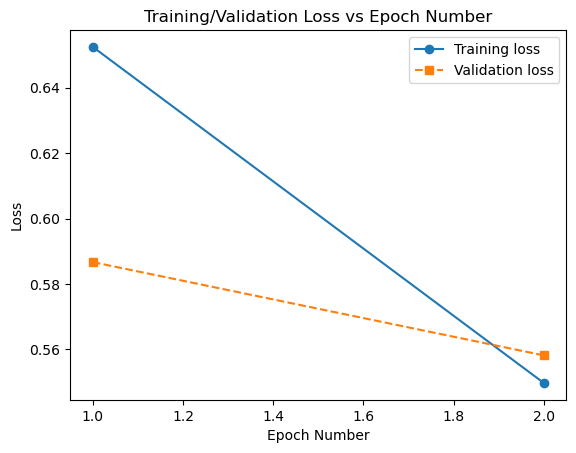

In [75]:
# Visualize the training/validation loss vs the epoch number
x = Output[0]
y1 = Output[1]
y2 = Output[2]

plt.plot(x, y1, label='Training loss', linestyle='-', marker='o')
plt.plot(x, y2, label='Validation loss', linestyle='--', marker='s')

plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.title('Training/Validation Loss vs Epoch Number')
plt.legend()
plt.show()

### 12. Test the model

In [76]:
#check model performance
def test(data_loader, model, criterion, margin):
    model.eval()  # Set model to evaluation mode
    total_loss = 0.0
    correct_triplets = 0
    total_triplets = 0

    with torch.no_grad():
        for anchor_data, positive_data, negative_data in data_loader:
            # Transfer data to the device
            anchor_data = anchor_data.to(device)
            positive_data = positive_data.to(device)
            negative_data = negative_data.to(device)

            # Forward pass
            anchor_out = model(anchor_data)
            positive_out = model(positive_data)
            negative_out = model(negative_data)

            # Calculate triplet loss
            loss = criterion(anchor_out, positive_out, negative_out)
            total_loss += loss.item()

            # Evaluate triplet condition
            distance_positive = F.pairwise_distance(anchor_out, positive_out, p=2)
            distance_negative = F.pairwise_distance(anchor_out, negative_out, p=2)

            correct_triplets += (distance_positive + margin < distance_negative).sum().item()
            total_triplets += len(distance_positive)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_triplets / total_triplets * 100

    print(f"Testing Loss: {avg_loss:.4f}, Triplet Accuracy: {accuracy:.2f}%")

In [77]:
test(final_test_data, model, criterion, margin = 1)

Testing Loss: 0.5628, Triplet Accuracy: 52.63%


### 13. Save the trained model parameters (weights and biases)

In [78]:
# Here we want to save our trained model

In [79]:
dt_now = str(datetime.now())[:10]

In [80]:
type(model.state_dict())

collections.OrderedDict

In [81]:
model.state_dict().keys()

odict_keys(['conv1.att_src', 'conv1.att_dst', 'conv1.bias', 'conv1.lin.weight', 'conv2.att_src', 'conv2.att_dst', 'conv2.bias', 'conv2.lin.weight', 'conv3.att_src', 'conv3.att_dst', 'conv3.bias', 'conv3.lin.weight', 'conv4.att_src', 'conv4.att_dst', 'conv4.bias', 'conv4.lin.weight'])

In [82]:
len(model.state_dict().keys())

16

In [83]:
main_file = 'modeldata'  # change the main file name if one day you want to change it
model_file = 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/'+main_file+'/m_wts_'+dt_now+'.pth'

In [84]:
torch.save(model.state_dict(),model_file)

### 14. Save the embeddings (learned representations or learned features)

In [85]:
# Here we want to generate the feature embeddings using the model,
# and then save it in pickle format to use it for visualization in the later part
# Sushima created the SIMPLE_GAT_visulaization.ipynb as an individual file to do this.

In [86]:
len(list(data_tuple.keys()))

80

In [87]:
list(data_tuple.keys())[0]

'gamma_100_reg_param_0.01_adh_0.01-Average-0'

In [88]:
data_tuple[list(data_tuple.keys())[0]]

Data(x=[886, 22], contact_edge_index=[2, 8940], lineage_edge_index=[2, 557])

In [89]:
data_tuple[list(data_tuple.keys())[0]].x

tensor([[ 1.0000e+00,  1.0000e+00,  1.0000e+00,  ..., -2.5200e-01,
         -1.5431e-17,  2.5200e-01],
        [ 2.0000e+00,  1.0000e+00,  1.0000e+00,  ..., -3.7302e-01,
         -2.2841e-17,  3.7302e-01],
        [ 3.0000e+00,  1.0000e+00,  1.0000e+00,  ..., -5.5216e-01,
         -3.3810e-17,  5.5216e-01],
        ...,
        [ 1.9000e+01,  4.9900e+02,  2.4900e+02,  ..., -8.1385e-01,
          2.1272e+00, -3.2562e-01],
        [ 1.9000e+01,  5.0000e+02,  2.5000e+02,  ..., -8.3500e-01,
          2.9099e+00, -3.0215e-01],
        [ 1.9000e+01,  5.0100e+02,  2.5100e+02,  ..., -1.4666e+00,
          2.9792e+00, -9.7252e-01]])

In [90]:
data_tuple[list(data_tuple.keys())[0]].x.shape  # [number of nodes, number of input features per node]

torch.Size([886, 22])

In [91]:
data_tuple[list(data_tuple.keys())[0]].contact_edge_index

tensor([[  3,   4,   5,  ..., 633, 633, 634],
        [  4,   3,   6,  ..., 632, 634, 633]])

In [92]:
data_tuple[list(data_tuple.keys())[0]].lineage_edge_index

tensor([[  3,   4,   7,  ..., 542, 544, 544],
        [  5,   6,  11,  ..., 883, 884, 885]])

In [93]:
# here we want to see how Sushima labeled the classes, so that we can reproduce the code to save the pickle files
with open("C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/modeldata/1000_simulation_data_40features50epoch.pickle", 'rb') as file:
    c_data_tuple = pk.load(file)  # this is the model feature outputs or embeddings
    
v_list = []
for k,v in c_data_tuple.items():
    if k.find(list(c_data_tuple.keys())[0][:-10])>=0:  # collect the class label for the class 'gamma_20_reg_param_0.1_adh_0.01'
        v_list.append(v[0])
v_list

[29, 29, 29, 29, 29, 29, 29, 29, 29, 29]

In [94]:
# as we can see, Sushima assign that class as label 29
# now we want to pair all the classes and their assigned labels
keys = list(set([g[:-10] for g in list(c_data_tuple.keys())]))
values = [-1]*100
class2label = {k:v for (k,v) in zip(keys, values)}  
for k,v in c_data_tuple.items():
    if class2label[k[:-10]] == -1:
        class2label[k[:-10]] = v[0]
if len(set(class2label.values())) == 100:
    print('Done')

Done


In [95]:
data_dict = {}
L = []
for k,v in data_tuple.items():  # k = key (or graph name), v = value (or input features of the graph)
    
    in_channels_model = 22
    hidden_channels_model = 4 #attention heads
    feature_embedding_size = 5
    
    model = GAT(in_channels=in_channels_model, hidden_channels=hidden_channels_model, out_channels=feature_embedding_size)
    model.load_state_dict(torch.load(model_file))
    model.eval()
    
    with torch.no_grad():
        out = model(v)
        embeddings = model.forward(v)
    
    e = embeddings
    c = class2label[k[:-10]]
    
    t = (c,v,e)  # t = tuple, c = class label, e = embeddings
    
    data_dict[k] = t
    L.append(t)

In [96]:
len(L)

80

In [97]:
len(data_dict.keys())

80

In [98]:
list(data_dict.keys())[0]

'gamma_100_reg_param_0.01_adh_0.01-Average-0'

In [99]:
data_dict[list(data_dict.keys())[0]]

(55,
 Data(x=[886, 22], contact_edge_index=[2, 8940], lineage_edge_index=[2, 557]),
 tensor([[ 0.7408,  1.1948, -0.8507, -0.7127,  9.8194]]))

In [186]:
embedding_file = 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/'+main_file+'/embeddings_'+dt_now+'.pkl'
with open(embedding_file, 'wb') as f:
    pk.dump(data_dict, f)

### 15. Model visualization using simulated datasets

Simple_GAT_visualization.ipynb

In [100]:
# load the generated feature set for simulations using the trained model
with open("C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/modeldata/1000_simulation_data_40features50epoch.pickle", 'rb') as file:
    c_data_tuple = pk.load(file)  # this is the model feature outputs or embeddings

In [101]:
with open("C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/modeldata/1000_simulation_data.pickle", 'rb') as file:
    c_data_tuple_0 = pk.load(file)

In [102]:
type(c_data_tuple)

dict

In [103]:
list(c_data_tuple.keys())[:3]

['gamma_20_reg_param_0.1_adh_0.01-Average-4',
 'gamma_10_reg_param_0.5_adh_100-Average-4',
 'gamma_20_reg_param_0.5_adh_1-Average-4']

In [104]:
len(list(c_data_tuple.keys()))

1000

In [105]:
c_data_tuple[list(c_data_tuple.keys())[0]]

(29,
 Data(x=[1193, 22], contact_edge_index=[2, 15770], lineage_edge_index=[2, 722]),
 tensor([[ 1.3084, -0.0249, -0.0264, -0.4834,  0.5822,  0.4828,  0.6101,  0.0370,
           0.6354, -0.5842,  0.8238,  0.6614, -0.1546,  0.1499, -0.1545, -0.5929,
           0.2600,  0.2647, -0.3407,  0.7486, -0.8079,  0.0200, -0.4387, -0.3797,
          -0.7426,  0.3058,  0.3052,  1.3476, -0.1735,  0.2576,  0.1301, -0.0236,
           0.6411, -0.3481, -0.2180, -0.0456,  0.9209,  0.0438,  1.5270,  0.1179]],
        requires_grad=True))

In [106]:
# check the first element of each tuple represents a number from 0 to 99 as the class label
len(set([c_data_tuple[list(c_data_tuple.keys())[i]][0] for i in range(len(list(c_data_tuple.keys())))]))

100

For each key, the value represents a tuple (class label, model feature input, model feature output) for a single graph sample.

In [107]:
tsne_x = []
tsne_y = []
for i in c_data_tuple.keys():
    k = list(c_data_tuple[i])
    tsne_x.append(k[2])
    tsne_y.append(k[0])

In [108]:
selected_classes = random.sample(range(1, 100), 5)
x_fil = []
y_fil = []
for i in range(len(tsne_y)):
    if  tsne_y[i] in selected_classes:
        x_fil.append(tsne_x[i])
        y_fil.append(tsne_y[i])

In [116]:
X = torch.cat(x_fil, dim=0)
X_emb = TSNE(n_components=2, perplexity=6, n_iter=300, verbose=True).fit_transform(X)

using cpu
initializing...
skipping PCA because initial_dims is larger than input dimensionality
computing p-values...


  0%|          | 0/50 [00:00<?, ?it/s]

fitting...


  0%|          | 0/300 [00:00<?, ?it/s]

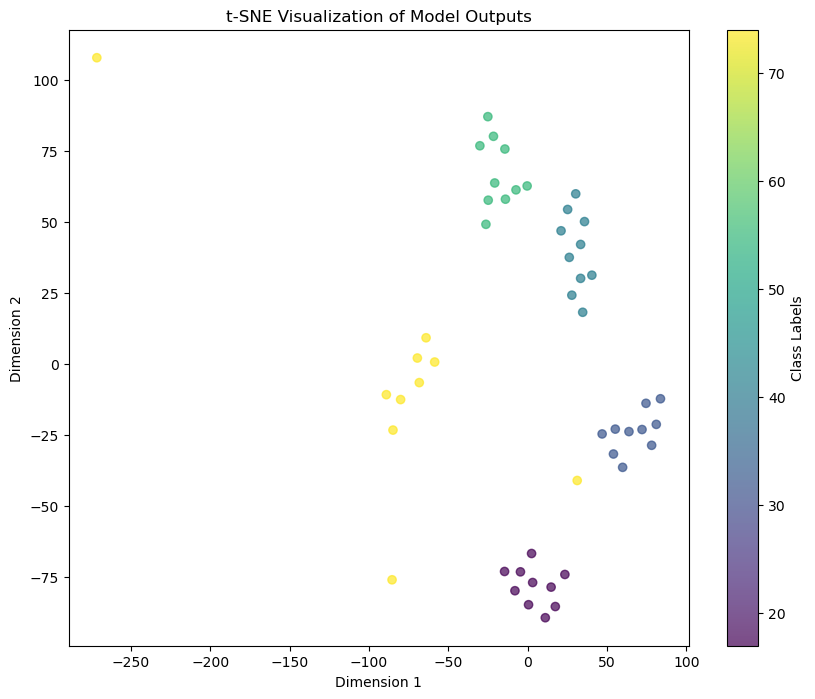

In [117]:
# Visualize
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=y_fil, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Class Labels")
plt.title("t-SNE Visualization of Model Outputs")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

In [187]:
# next section will be using the experimental data, so it's already the end of simulated data part

### 16. Graph verification using the experimental datasets

Generated_graph_verification.ipynb

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

In [25]:
path = 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/Output-ImageProcessing+PostProcessing/24-1-23.scene8/'
# Load the CSV data
filter_objects_path = path + 'FilterObjects-Average-analysis.csv'
object_relationships_path = path + 'Object relationships.csv'

In [26]:
filter_df = pd.read_csv(filter_objects_path.replace('/','//'))
relationship_df = pd.read_csv(object_relationships_path.replace('/','//'))

filter_df.head(2)

,stepNum,ObjectNumber,AreaShape_Area,AreaShape_BoundingBoxArea,AreaShape_BoundingBoxMaximum_X,AreaShape_BoundingBoxMaximum_Y,AreaShape_BoundingBoxMinimum_X,AreaShape_BoundingBoxMinimum_Y,AreaShape_Center_X,AreaShape_Center_Y,...,startVol,targetVol,pos,time,radius,dir,ends,strainRate,strainRate_rolling,unknown_cell_type
0,1,1,214,432,372,324,345,308,51.547290,45.461607,...,4.479559,4.842627,"[51.54728971962617, 45.461607476635514]",3.0,0.650006,"[-0.9193701251357749, -0.3933936616264039]","[[49.48810340614666, 44.580492437454694], [53....",0.000000,0.000000,False
1,2,1,209,432,372,324,345,308,51.536153,45.467483,...,4.479559,4.842627,"[51.53615311004785, 45.46748325358852]",6.0,0.626402,"[-0.922610651928921, -0.38573253032028737]","[[49.44722224555754, 44.59412612689661], [53.6...",0.010882,0.005441,False


In [27]:
relationship_df.head(2)

,Module,Module Number,Relationship,First Object Name,First Image Number,First Object Number,Second Object Name,Second Image Number,Second Object Number
0,MeasureObjectNeighbors,9,Neighbors,FilterObjects,4,1,FilterObjects,4,2
1,MeasureObjectNeighbors,9,Neighbors,FilterObjects,4,2,FilterObjects,4,1


In [28]:
# Convert nested list columns to individual tuple columns
filter_df['pos'] = filter_df['pos'].apply(eval).apply(lambda x: tuple(x))
filter_df['dir'] = filter_df['dir'].apply(eval).apply(lambda x: tuple(x))
filter_df[['ends0', 'ends1']] = filter_df['ends'].apply(eval).apply(pd.Series)
filter_df['ends0'] = filter_df['ends0'].apply(lambda x: tuple(x))
filter_df['ends1'] = filter_df['ends1'].apply(lambda x: tuple(x))

In [29]:
# Select required columns
include_columns = ['stepNum', 'id', 'ObjectNumber', 'parent_id', 'label', 'cellType', 'divideFlag', 'growthRate',
                   'LifeHistory', 'startVol', 'targetVol', 'pos', 'radius', 'length', 'dir',
                   'ends0', 'ends1', 'strainRate', 'strainRate_rolling']
node_features = filter_df[include_columns].copy().query('stepNum<=15')

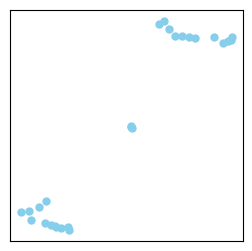

In [30]:
# Create the graph
G = nx.Graph()

# Add nodes with their features as attributes and label them by their index
for idx, row in node_features.iterrows():
    node_id = idx  # Use the index as a unique label for each node
    G.add_node(node_id, **row.to_dict())

# Define positions for the entire graph
pos = {node: data['pos'] for node, data in G.nodes(data=True)}

# Plot the entire graph
plt.figure(figsize=(3, 3))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=25, node_color='skyblue')

In [31]:
# Create a unique mapping from (stepNum, ObjectNum) to node index
node_mapping = {(row['stepNum'], row['ObjectNumber']): idx for idx, row in node_features.iterrows()}

# Add edges, considering contact edges
for _, row in relationship_df[relationship_df['First Image Number']<=15].iterrows():
    if row['Relationship'] == 'Neighbors':
        step_num_1 = row['First Image Number']
        step_num_2 = row['Second Image Number']
        node1 = row['First Object Number']
        node2 = row['Second Object Number']

        if (step_num_1, node1) in node_mapping and (step_num_2, node2) in node_mapping:
            if not G.has_edge(node_mapping[(step_num_1, node1)], node_mapping[(step_num_2, node2)]):
                node1_idx = node_mapping[(step_num_1, node1)]
                node2_idx = node_mapping[(step_num_2, node2)]
                G.add_edge(node1_idx, node2_idx)

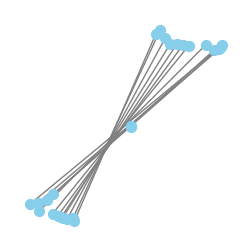

In [32]:
# Plot the entire graph
plt.figure(figsize=(3, 3))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='skyblue')

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gray')

plt.axis('off')
plt.show()

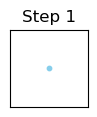

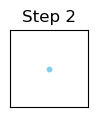

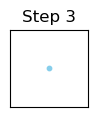

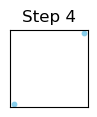

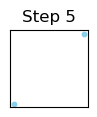

In [37]:
#Simulating every time step for verification
for i in range(1, 6):  # change it to larger number for more nodes when it is needed for paper work or presentation
    features = filter_df[filter_df['stepNum']==i]
    # Create the graph
    H = nx.Graph()

    # Add nodes with their features as attributes and label them by their index
    for idx, row in features.iterrows():
        node_id = idx  # Use the index as a unique label for each node
        H.add_node(node_id, **row.to_dict())

    # Define positions for the entire graph
    pos = {node: data['pos'] for node, data in G.nodes(data=True)}

    # Plot the entire graph
    plt.figure(figsize=(1, 1))

    # Draw nodes
    nx.draw_networkx_nodes(H, pos, node_size=10, node_color='skyblue')
    plt.title(f'Step {i}')
    plt.show()

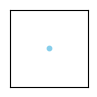

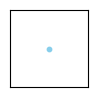

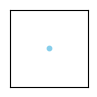

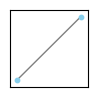

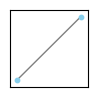

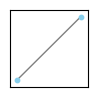

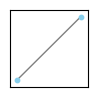

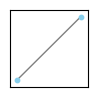

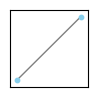

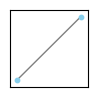

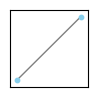

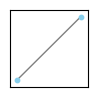

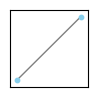

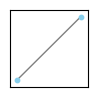

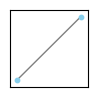

In [40]:
# make an undirected copy of the digraph
UG = G.to_undirected()

A = list(UG.subgraph(c) for c in nx.connected_components(UG))

for i in A:
    plt.figure(figsize=(1,1))
    pos = {node: data['pos'] for node, data in i.nodes(data=True)}
    nx.draw_networkx_nodes(i, pos, node_size=10, node_color='skyblue')
    nx.draw_networkx_edges(i, pos, edge_color='gray')
    #plt.axis('off')
    plt.show()